Update as needed and hit run all

In [55]:
### Run the line below if PSG_POWER_PYTHON is not installed
!pip install --upgrade somnopy
!pip install --upgrade yasa

In [56]:
# ----------------- Load packages ------------------- #
import os
import contextlib
import io
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime




from somnopy import *
from somnopy.somno import get_sosp, get_sosp_for_folder
from somnopy.event_detection import SO_detection, SP_detection, detect_swa
from somnopy.metrics import pac,event_lock
from somnopy.utils import set_up_raw
from somnopy.polysomnography import PolySomnoGraphy
import yasa


In [57]:
###The following are REQUIRED PARAMETERS:

# data_path should point to a folder of folders. Each folder within data_path will have its .edf and .txt / .mat contents analyzed separately
# output_path should point to a folder where you want to store your results. 

# Subfolders within output_path will match the names of the subfolders within data_path
# If matching subfolders have not been created yet, they will be created automatically 
# Each subfolder will store results for the corresponding .edf files in data_path

# Group data into subfolders however you would like. If you want metrics per participant, make sure each .edf and .txt / .mat
# file is stored in it's own subfolder in data_path per participant. If you want metrics across all participants, just
# create one subfolder within data_path for all .edf and .txt files

# Make sure each .edf filename matches its corresponding .txt / .mat file

data_path = r"C:\Users\Beast\Ryan\somnopy\somnopy\data" 
output_path = r"C:\Users\Beast\Ryan\somnopy\somnopy\output" 


###The following are OPTIONAL PARAMETERS, the default value is what you see, update as necessary:
interest_stage = ('N2', 'SWS') #sleep stages interested in evaluating
sp_method = 'Hahn2020' #Method used for spindle detection. See available methods below
so_method = 'Staresina' #Method used for slow oscillation detection. See available methods below
coupling = True #If set to true, additional metrics such as PAC, or spindle to slow oscillation coupling percentage will be calulated and plotted
scoring_dur = 30 # (in seconds) the duration of each epoch used for sleep scoring
rereference = False # If reference channels are not contralateral mostoids or you are unsure, otherwise set to: rereference = ['M1', 'M2'], also optional to set 'average' to use the average of all channels as reference
chan_limit = ['F3', 'C3', 'F4', 'C4'] # Use None to process all channels, or use ['Fz', 'Cz', 'F3', 'C3', ...] to process selected channels only.
channels_to_drop = ('E1', 'E2', 'ChinC', 'ChinL', 'ChinR') #by default, will drop non-eeg channels. Add any channels that you would want to drop completely
montage_temp = "standard_1005" # Use standard_1005 for mid and high-density caps, standard_1020 for low-density caps, or specify another montage. See other available montages below
baseline = True # Baseline correction before the event detection
verbose = True # Additional diagnostic plotting/ printing if set to true
#The following are customisable Slow Oscillatoin detection metrics, that have different default depending on method used
filter_freq = None
duration = None
filter_type = 'fir'
#The following are customisable Spindle detection metrics, that have different default depending on method used
l_freq = None
h_freq = None
dur_lower = None
dur_upper = None


In [58]:
#get the folder paths to pass into the get_sosp_for_folder function
folder_paths = [str(p) for p in Path(data_path).iterdir() if p.is_dir()]
folder_paths


['C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\data\\dummy',
 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\data\\participant1',
 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\data\\participant2',
 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\data\\preproc',
 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\data\\scoring']

RUNNING C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy
Start event detection for subject MD_01.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 104.6080
Mean Duration: 1.2836
SO Density per 30s: 3.0000
Total Count: 432
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 266.1300
Mean Duration: 1.2046
SO Density per 30s: 2.9535
Total Count: 1524
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 9.5058 uv
Average Duration: 0.8104s
Spindle Density (per 30s): 2.9653
Total Spindle Count: 427
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 8.1224 uv
Average Duration: 0.7925s
Spindle Density (per 30s): 3.2267
Total Spindle Count: 1665
--------------------------------------------------

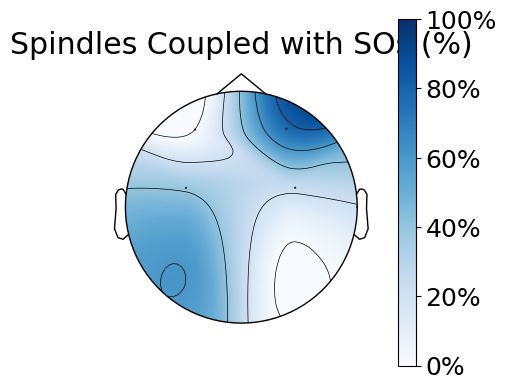

Stage N2:
Preferred Phase:       2.822 rad
Modulation Index:      0.030
Mean Vector Length:    0.051
Rayleigh z:            0.439
p-value:               0.928
Coupling Density:      1.870
Stage SWS:
Preferred Phase:       -3.127 rad
Modulation Index:      0.013
Mean Vector Length:    0.158
Rayleigh z:            12.638
p-value:               0.000
Coupling Density:      1.638


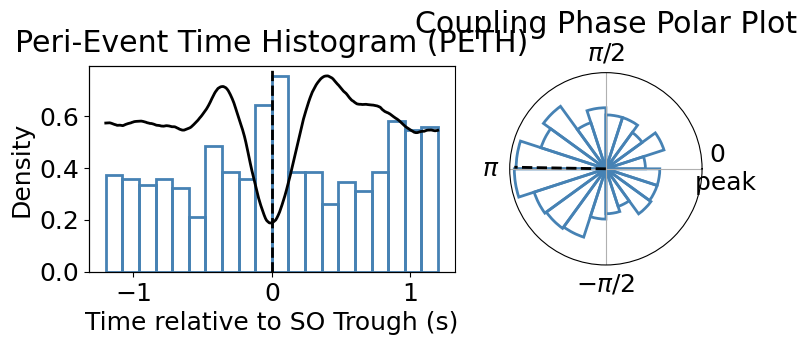

📄 Saved: C:\Users\Beast\Ryan\somnopy\somnopy\output\dummy\MD_01_somnopy_summary_2026-03-09.csv
✅ Finished C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy in 0m 49s


In [59]:
#run coupling analysis
#figs should auto save out
#figs now save, future should stem all info (datetime included) and pass to function calls. Currently overwrites past figs

today_str = datetime.now().strftime("%Y-%m-%d")


#run through all participant folders
for folder in folder_paths:
    folder_path = Path(folder)
    folder_name = folder_path.name
    output_folder = Path(output_path) / folder_name 
    output_folder.mkdir(parents=True, exist_ok=True)

    print(f"RUNNING {folder}")
    
    #try running SOSP
    try:
        start_time = time.time()
        #run analysis function
        event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
            folder,
            folder,
            chan_limit=chan_limit,
            coupling=coupling,
            interest_stage=interest_stage,
            sp_method=sp_method,
            so_method=so_method,
            scoring_dur=scoring_dur,
            outpath = output_folder
        )
        
        #save summary for each eeg file within single participant as csv. From what I understand, there should only be one of these typically
        for filename, summary in event_summary_all.items():
            stem = Path(filename).stem  
            csv_path = output_folder / f"{stem}_somnopy_summary_{today_str}.csv"

            summary.to_csv(csv_path, index=False)
            print(f"📄 Saved: {csv_path}")
            
        end_time = time.time()
        duration = end_time - start_time
        print(f"✅ Finished {folder} in {int(duration//60)}m {int(duration%60)}s")

    except Exception as e:
        print(f"❌ Error processing {folder}: {e}")

    #uncomment if you want to try just the first folder
    break 


    


# Spectrogram: EDF files

In [ ]:

test_path = r"Y:\SNL\EmoCuing\Data\PSG Data\EMO Cuing\EmoCuing001.edf"
raw = mne.io.read_raw_edf(test_path, preload=True)
raw_data = raw.get_data()
channels = raw.ch_names
sampling_rate = raw.info["sfreq"]
times = raw_data / sampling_rate



Extracting EDF parameters from Y:\SNL\EmoCuing\Data\PSG Data\EMO Cuing\EmoCuing001.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 13634499  =      0.000 ... 27268.998 secs...


# Spectrogram: BrainVision EEG files

In [51]:
channels

['EOG1', 'EOG2', 'F3', 'F4', 'C3', 'C4', 'O1', 'O2', 'CHIN1']

In [45]:
cz_idx = next(i for i, ch in enumerate(channels) if ch.strip().upper() in {"F3", "EEG CZ", "EEG:CZ", "Cz".upper()})
data_cz = raw_data[cz_idx, :]

print("Cz index:", cz_idx, "name:", channels[cz_idx])
data_cz.shape

[i for i, ch in enumerate(channels) if "CZ" in ch.upper()], [ch for ch in channels if "CZ" in ch.upper()]


Cz index: 0 name: F3


([], [])

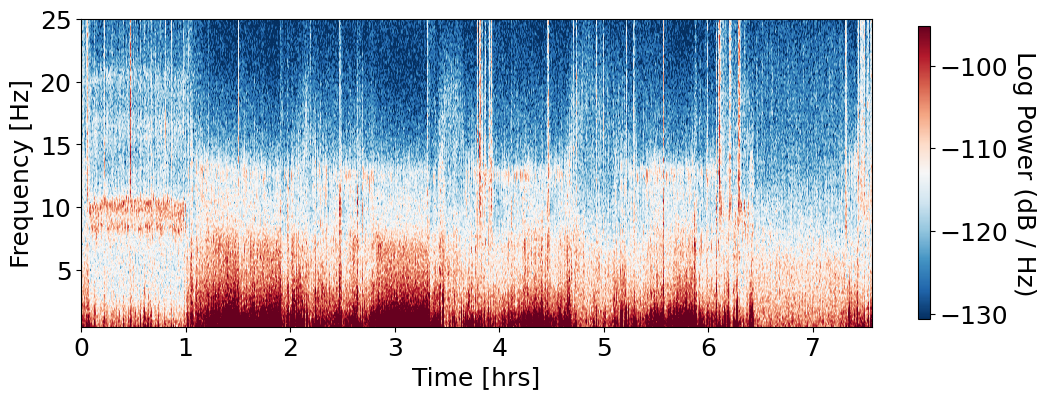

In [54]:
fig = yasa.plot_spectrogram(raw_data[2], sampling_rate)

In [42]:
print(np.round(raw_data[:, 0:5], 3))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [22]:
raw_data = raw.get_data()

In [25]:
raw.ch_names

['F3',
 'C3',
 'O1',
 'F4',
 'C4',
 'O2',
 'E1',
 'E2',
 'M1',
 'M2',
 'ChinC',
 'ChinL',
 'ChinR']

In [20]:
print(today_str)

2026-03-05


In [4]:
### Available Spindle detection methods:

'''
1) hahn2020 (default)
       - 12-16 Hz bandpass filter, Hilbert transform to obtain amplitude envelope,
         thresholded at a given percentile (default 75th),
         with a duration criterion of 0.5 to 3 seconds.

    2) martin2013
       - 11-15 Hz bandpass filter (linear phase FIR, forward and reverse for 0-phase distortion).
       - Compute RMS of the filtered signal with a 0.25 s time window.
       - Threshold at its 95th percentile (published criteria: Schabus et al., 2007).
       - A spindle is identified if at least two consecutive RMS time points
         exceed the threshold, and total duration >= 0.5 s.

    3) wamsley2012
       - Discrete sleep spindle events detected using a wavelet-based algorithm
         with an 8-parameter complex Morlet wavelet, ~10-16 Hz range.
       - Spindles are identified at each channel by a thresholding algorithm
         applied to the wavelet scale corresponding to 10-16 Hz.
       - The rectified moving average of this wavelet signal is calculated
         with a 100 ms sliding window.
       - Threshold = 4.5 times the mean signal amplitude across artifact-free epochs.
       - Duration >= 0.4 s to count as a spindle.

    4) Wendt2012
       - The raw data are bandpass filtered between 11-16 Hz.
       - The signal is then rectified.
       - Two separate lowpass filters are applied to create two envelopes
         (one ~2.25 Hz passband with offset 3 μV, the other ~1 Hz passband with offset 8 μV).
       - A time-varying threshold is formed by each envelope + offset.
       - Any rectified signal crossing either threshold boundary within 0.5-3 s
         is considered a spindle candidate. A final decision fusion is applied

    5) Ferrarelli2007
       - 12-15 Hz bandpass filter (–3 dB at 12 and 15 Hz).
       - The amplitude of the rectified filtered signal is used as the time series.
       - If the signal's amplitude exceeds an upper threshold (8 × channel average amplitude),
         it is considered a spindle candidate. Peak amplitude is the local maximum above
         that threshold. The start and end are the preceding/following points
         where amplitude drops below a lower threshold (2 × channel average amplitude).
       - Duration >= 0.5 s is typically required (AASM-based).
'''

"\n1) hahn2020 (default)\n       - 12-16 Hz bandpass filter, Hilbert transform to obtain amplitude envelope,\n         thresholded at a given percentile (default 75th),\n         with a duration criterion of 0.5 to 3 seconds.\n\n    2) martin2013\n       - 11-15 Hz bandpass filter (linear phase FIR, forward and reverse for 0-phase distortion).\n       - Compute RMS of the filtered signal with a 0.25 s time window.\n       - Threshold at its 95th percentile (published criteria: Schabus et al., 2007).\n       - A spindle is identified if at least two consecutive RMS time points\n         exceed the threshold, and total duration >= 0.5 s.\n\n    3) wamsley2012\n       - Discrete sleep spindle events detected using a wavelet-based algorithm\n         with an 8-parameter complex Morlet wavelet, ~10-16 Hz range.\n       - Spindles are identified at each channel by a thresholding algorithm\n         applied to the wavelet scale corresponding to 10-16 Hz.\n       - The rectified moving average

In [5]:
### Available Slow Oscillation detection methods:

'''
    'Staresina': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},
    'Ng': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},
    'Massimini': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},
    'Dimulescu': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},
    'Molle': {'filter_freq': (0.1, 2), 'duration': (0.9, 2)},
    'Ngo': {'filter_freq': (None, 3.5), 'duration': (0.9, 2)}
'''

"\n    'Staresina': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},\n    'Ng': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},\n    'Massimini': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},\n    'Dimulescu': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},\n    'Molle': {'filter_freq': (0.1, 2), 'duration': (0.9, 2)},\n    'Ngo': {'filter_freq': (None, 3.5), 'duration': (0.9, 2)}\n"

In [6]:
### Available Montages

# standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
# standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
# standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
# standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
# standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
# standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
# biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
# biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
# biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
# biosemi128: BioSemi cap with 128 electrodes (128+3 locations)
# biosemi160: BioSemi cap with 160 electrodes (160+3 locations)
# biosemi256: BioSemi cap with 256 electrodes (256+3 locations)
# easycap-M1: EasyCap with 10-05 electrode names (74 locations)
# easycap-M10: EasyCap with numbered electrodes (61 locations)
# easycap-M43: EasyCap with numbered electrodes (64 locations)
# EGI_256: Geodesic Sensor Net (256 locations)
# GSN-HydroCel-32: HydroCel Geodesic Sensor Net and Cz (33+3 locations)
# GSN-HydroCel-64_1.0: HydroCel Geodesic Sensor Net (64+3 locations)
# GSN-HydroCel-65_1.0: HydroCel Geodesic Sensor Net and Cz (65+3 locations)
# GSN-HydroCel-128: HydroCel Geodesic Sensor Net (128+3 locations)
# GSN-HydroCel-129: HydroCel Geodesic Sensor Net and Cz (129+3 locations)
# GSN-HydroCel-256: HydroCel Geodesic Sensor Net (256+3 locations)
# GSN-HydroCel-257: HydroCel Geodesic Sensor Net and Cz (257+3 locations)
# mgh60: The (older) 60-channel cap used at MGH (60+3 locations)
# mgh70: The (newer) 70-channel BrainVision cap used at MGH (70+3 locations)
# artinis-octamon: Artinis OctaMon fNIRS (8 sources, 2 detectors)
# artinis-brite23: Artinis Brite23 fNIRS (11 sources, 7 detectors)
# brainproducts-RNP-BA-128: Brain Products with 10-10 electrode names (128 channels)

Start event detection for subject MD_01.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 104.6080
Mean Duration: 1.2836
SO Density per 30s: 3.0000
Total Count: 432
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 266.1300
Mean Duration: 1.2046
SO Density per 30s: 2.9535
Total Count: 1524
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 9.5058 uv
Average Duration: 0.8104s
Spindle Density (per 30s): 2.9653
Total Spindle Count: 427
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 8.1224 uv
Average Duration: 0.7925s
Spindle Density (per 30s): 3.2267
Total Spindle Count: 1665
---------------------------------------------------------------
Spindles coupled with SOs in stage N2: 47

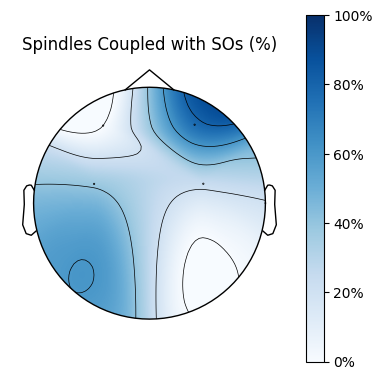

Stage N2:
Preferred Phase:       2.822 rad
Modulation Index:      0.030
Mean Vector Length:    0.051
Rayleigh z:            0.439
p-value:               0.928
Coupling Density:      1.870
Stage SWS:
Preferred Phase:       -3.127 rad
Modulation Index:      0.013
Mean Vector Length:    0.158
Rayleigh z:            12.638
p-value:               0.000
Coupling Density:      1.638


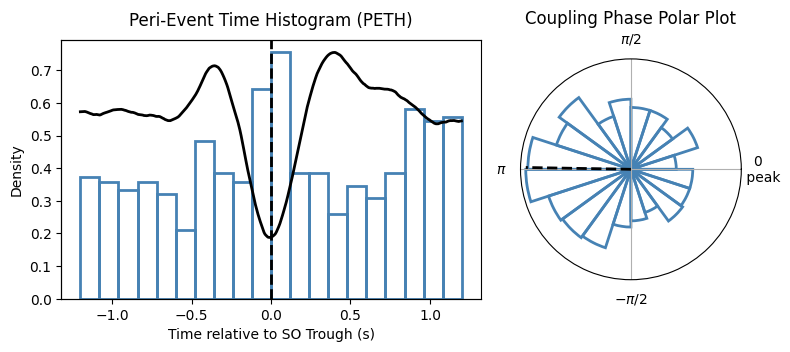

Execution time: 0 hours, 0 minutes, 48 seconds


In [5]:



start_time = time.time()

#
# If you have updated any values from the default, you should add them the same way that chan_limit = chan_limit is set here.
#

event_summary_all, coupling_event_all, so_waveform_all=get_sosp_for_folder(processed_eeg_folder, scoring_file, chan_limit = chan_limit, coupling = coupling)

end_time = time.time()

execution_time_seconds = end_time - start_time

hours = int(execution_time_seconds // 3600)
minutes = int((execution_time_seconds % 3600) // 60)
seconds = int(execution_time_seconds % 60)

print(f"Execution time: {hours} hours, {minutes} minutes, {seconds} seconds")

In [8]:
psg = PolySomnoGraphy('data/MD_02.edf', hypnogram_path='data/MD_02.txt', hypnogram_type='RemLogic',
                                      skip_header=True, interval=scoring_dur,
                                      bad_epoch=True,  chan_limit=chan_limit, 
                                      montage_temp=montage_temp, is_montage=True)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Detected SOs in stage N2
Method: Staresina
PTP amplitude: 116.7232
Mean Duration: 1.2921
SO Density per 30s: 3.5652
Total Count: 984
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 243.4637
Mean Duration: 1.2200
SO Density per 30s: 3.6967
Total Count: 1109
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 13.1341 uv
Average Duration: 0.8882s
Spindle Density (per 30s): 3.7754
Total Spindle Count: 1042
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 12.2879 uv
Average Duration: 0.8292s
Spindle Density (per 30s): 3.7033
Total Spindle Count: 1111
---------------------------------------------------------------
Spindles coupled with SOs in stage N2: 59.21%
SOs coupled with spindles in stage N2: 62.70%
Spindles coupled with SOs in stage SWS: 52.84%
SOs coupled with spi

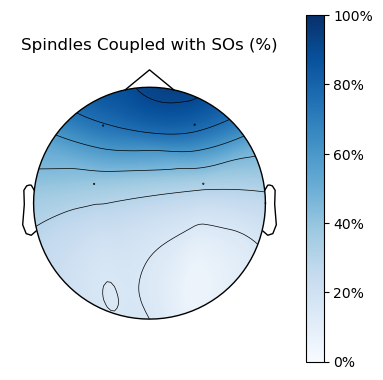

Stage N2:
Preferred Phase:       -0.882 rad
Modulation Index:      0.007
Mean Vector Length:    0.048
Rayleigh z:            1.173
p-value:               0.673
Coupling Density:      2.236
Stage SWS:
Preferred Phase:       1.939 rad
Modulation Index:      0.016
Mean Vector Length:    0.071
Rayleigh z:            2.398
p-value:               0.309
Coupling Density:      1.957


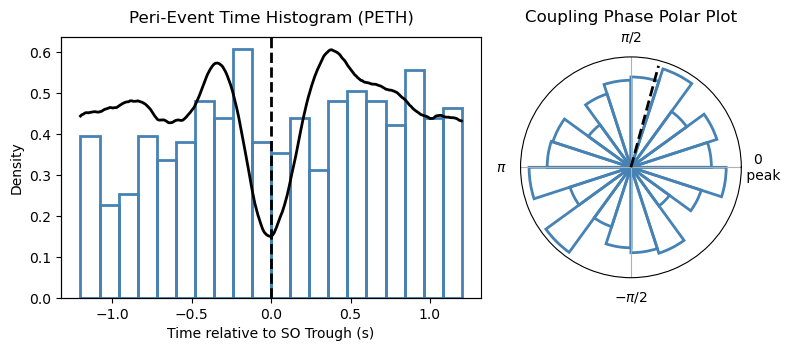

In [9]:
test1, so_candidate, so_summary = psg.detect_slow_oscillations(target_stage=interest_stage, method=so_method,
                                                               baseline=baseline, verbose=verbose,
                                                               filter_freq=filter_freq,
                                                               duration=duration, filter_type=filter_type)
test2, sp_candidate, sp_summary = psg.detect_spindles(target_stage=interest_stage, method=sp_method,
                                                  l_freq=l_freq, h_freq=h_freq, dur_lower=dur_lower,
                                                  dur_upper=dur_upper, baseline=baseline, verbose=verbose)
event_summary = pd.merge(so_summary, sp_summary, on=['stage'], how='outer')

cp_event = None
so_waveform = None

event_summary, so_waveform = psg.pac(verbose=verbose, file_name='MD_02')

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Massimini
PTP amplitude: 197.8731
Mean Duration: 1.1702
SO Density per 30s: 0.6739
Total Count: 186
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Massimini
PTP amplitude: 249.6265
Mean Duration: 1.0911
SO Density per 30s: 4.9933
Total Count: 1498
---------------------------------------------------------------
Detected SPs in stage N2
Method: Wamsley2012
Average Amplitude: 156.0227 uv
Average Duration: 0.5954s
Spindle Density (per 30s): 0.5000
Total Spindle Count: 138
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Wamsley2012
Average Amplitude: 156.8733 uv
Average Duration: 0.5344s
Spindle Density (per 30s): 0.2567
Total Spindle Count: 77
---------------------------------------------------------------
Spindles coupled with SOs in stage N2: 11.59%
SOs coupled with spindles in

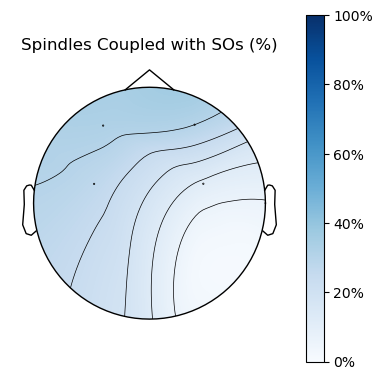

Stage N2:
Preferred Phase:       -0.042 rad
Modulation Index:      0.251
Mean Vector Length:    0.319
Rayleigh z:            1.327
p-value:               0.617
Coupling Density:      0.077
Stage SWS:
Preferred Phase:       -1.095 rad
Modulation Index:      0.154
Mean Vector Length:    0.116
Rayleigh z:            0.379
p-value:               0.944
Coupling Density:      0.120


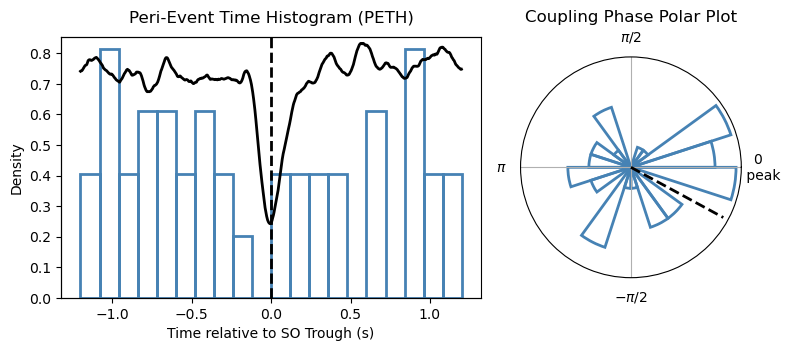

In [10]:
psg_1 = PolySomnoGraphy('data/MD_02.edf', hypnogram_path='data/MD_02.txt', hypnogram_type='RemLogic',
                                      skip_header=True, interval=scoring_dur,
                                      bad_epoch=True,  chan_limit=chan_limit, 
                                      montage_temp=montage_temp, is_montage=True)
test1, so_candidate_1, so_summary_1 = psg_1.detect_slow_oscillations(target_stage=interest_stage, method='Massimini',
                                                               baseline=baseline, verbose=verbose,
                                                               filter_freq=filter_freq,
                                                               duration=duration, filter_type=filter_type)
test2, sp_candidate_1, sp_summary_1 = psg_1.detect_spindles(target_stage=interest_stage, method='Wamsley2012',
                                                  l_freq=l_freq, h_freq=h_freq, dur_lower=dur_lower,
                                                  dur_upper=dur_upper, baseline=baseline, verbose=verbose)
event_summary_1 = pd.merge(so_summary_1, sp_summary_1, on=['stage'], how='outer')

cp_event_1 = None
so_waveform_1 = None

event_summary_1, so_waveform_1 = psg_1.pac(verbose=verbose, file_name='MD_02')


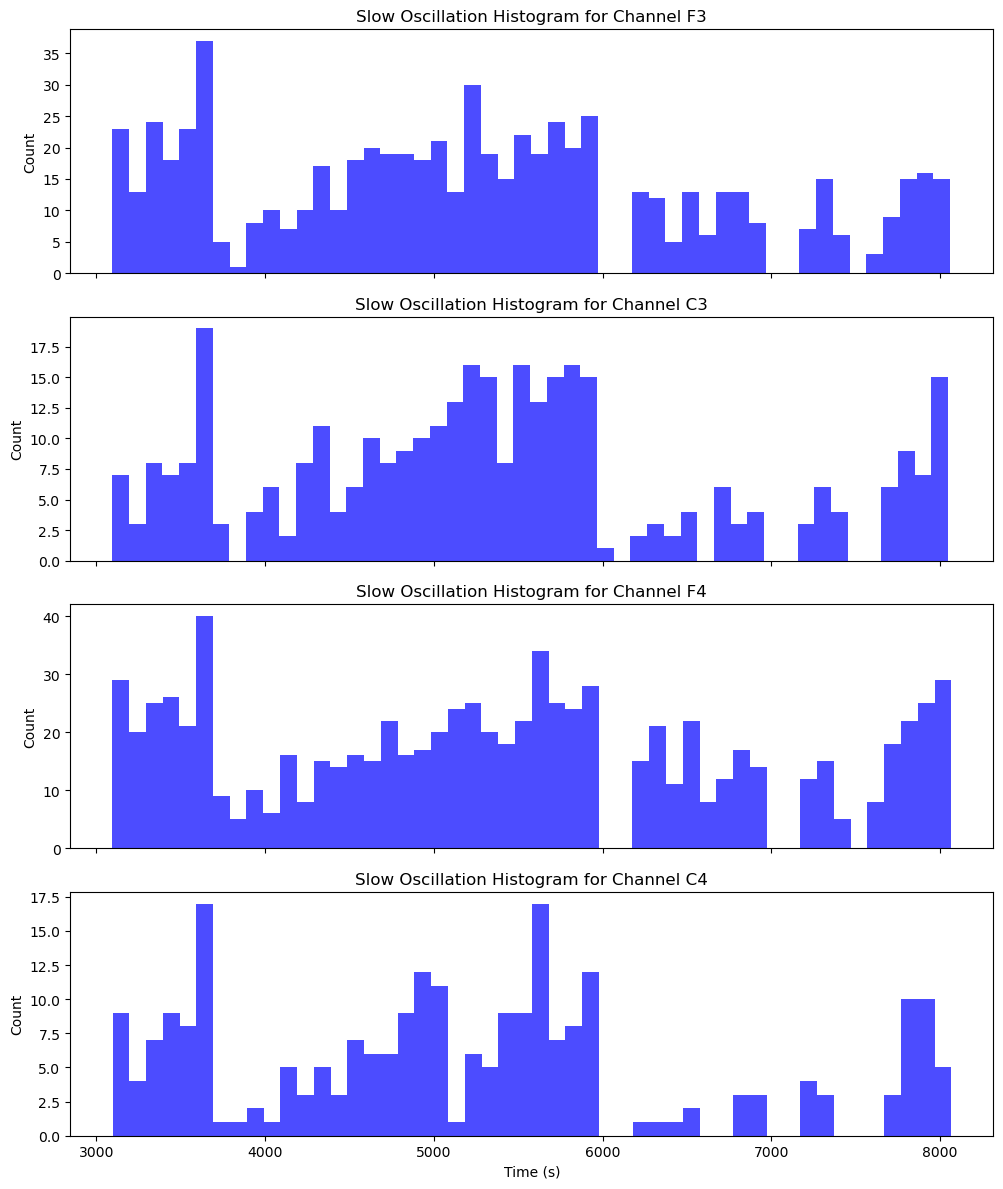

In [11]:
channels = so_candidate['ch_name'].unique()
n_channels = len(channels)

# Create a figure with one subplot per channel
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)

# If there's only one channel, ensure axes is iterable
if n_channels == 1:
    axes = [axes]

# Loop over channels and plot the histogram for each
for ax, ch in zip(axes, channels):
    # Filter data for the current channel
    channel_data = so_candidate[so_candidate['ch_name'] == ch]
    
    # Plot histogram of spindle start times
    ax.hist(channel_data['p2n_start'], bins=50, color='blue', alpha=0.7)
    ax.set_title(f"Slow Oscillation Histogram for Channel {ch}")
    ax.set_ylabel("Count")
    
# Set common x-axis label
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

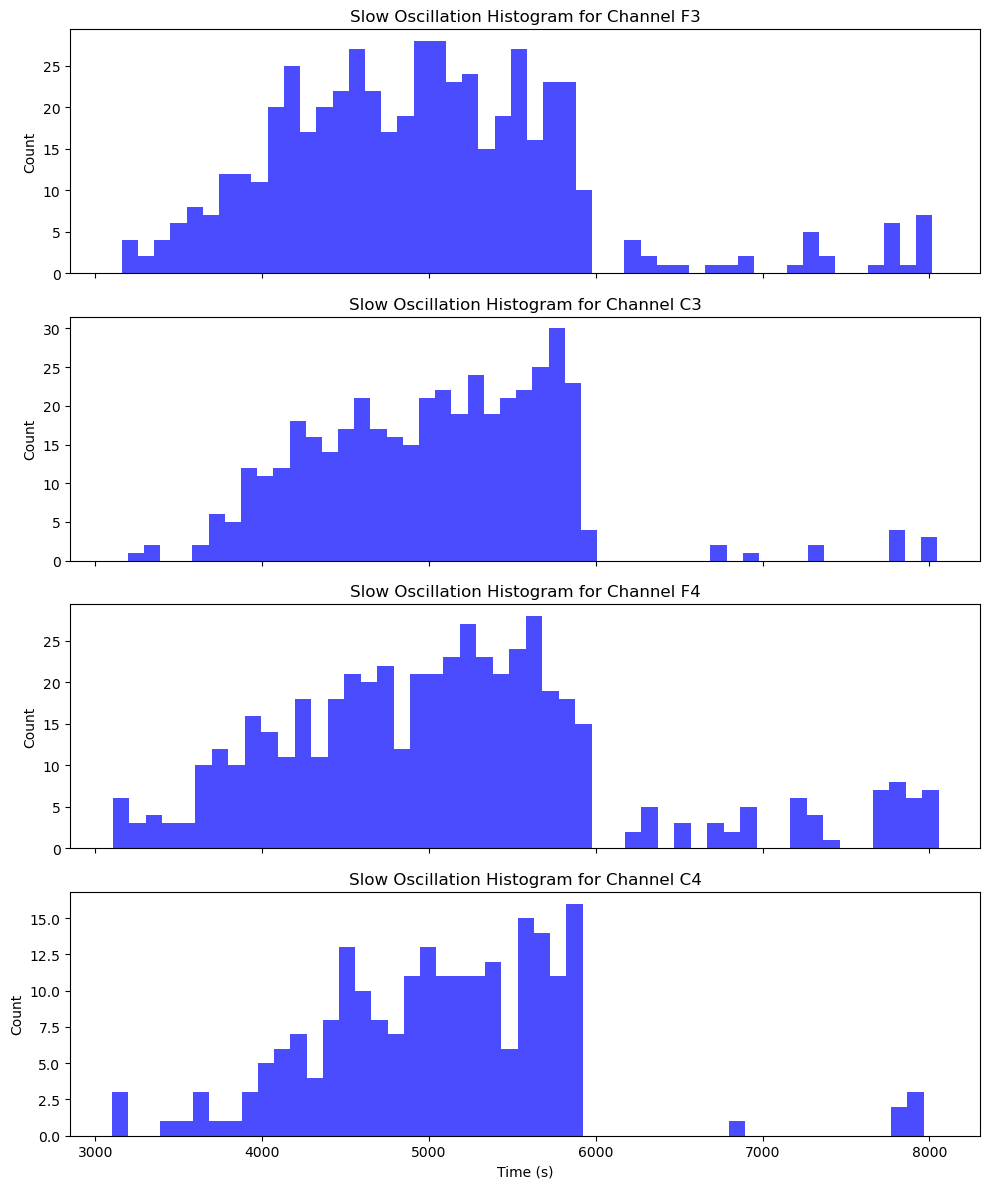

In [12]:
channels = so_candidate_1['ch_name'].unique()
n_channels = len(channels)

# Create a figure with one subplot per channel
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)

# If there's only one channel, ensure axes is iterable
if n_channels == 1:
    axes = [axes]

# Loop over channels and plot the histogram for each
for ax, ch in zip(axes, channels):
    # Filter data for the current channel
    channel_data = so_candidate_1[so_candidate_1['ch_name'] == ch]
    
    # Plot histogram of spindle start times
    ax.hist(channel_data['p2n_start'], bins=50, color='blue', alpha=0.7)
    ax.set_title(f"Slow Oscillation Histogram for Channel {ch}")
    ax.set_ylabel("Count")
    
# Set common x-axis label
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [13]:
#TODO: Start with modeling sleep stages.

from collections import Counter

concurrent_spindles = []

for sp in sp_candidate[sp_candidate['ch_name']=='F3'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate[(sp_candidate['ch_name']=='C3') & sp_candidate['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('3 backward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate[sp_candidate['ch_name']=='C3'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate[(sp_candidate['ch_name']=='F3') & sp_candidate['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('3 forward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate[sp_candidate['ch_name']=='F4'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate[(sp_candidate['ch_name']=='C4') & sp_candidate['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('4 backward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate[sp_candidate['ch_name']=='C4'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate[(sp_candidate['ch_name']=='F4') & sp_candidate['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('4 forward', Counter(concurrent_spindles))





print(len(sp_candidate[sp_candidate['ch_name']=='F3']))
print(len(sp_candidate[sp_candidate['ch_name']=='F4']))
print(len(sp_candidate[sp_candidate['ch_name']=='C3']))
print(len(sp_candidate[sp_candidate['ch_name']=='C4']))


3 backward Counter({0: 380, 1: 151})
3 forward Counter({0: 367, 1: 157})
4 backward Counter({0: 371, 1: 162})
4 forward Counter({0: 422, 1: 143})
531
533
524
565


In [14]:
#TODO: Start with modeling sleep stages.

from collections import Counter

concurrent_spindles = []

for sp in sp_candidate_1[sp_candidate_1['ch_name']=='F3'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate_1[(sp_candidate_1['ch_name']=='C3') & sp_candidate_1['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('3 backward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate_1[sp_candidate_1['ch_name']=='C3'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate_1[(sp_candidate_1['ch_name']=='F3') & sp_candidate_1['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('3 forward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate_1[sp_candidate_1['ch_name']=='F4'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate_1[(sp_candidate_1['ch_name']=='C4') & sp_candidate_1['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('4 backward', Counter(concurrent_spindles))

concurrent_spindles = []

for sp in sp_candidate_1[sp_candidate_1['ch_name']=='C4'].itertuples():
    concurrent = 0
    stime = sp.start_time
    spf4 = sp_candidate_1[(sp_candidate_1['ch_name']=='F4') & sp_candidate_1['start_time'].between(stime,stime+0.5)]
    if spf4 is not None:
        concurrent +=len(spf4)

    concurrent_spindles.append(concurrent)

print('4 forward', Counter(concurrent_spindles))





print(len(sp_candidate_1[sp_candidate_1['ch_name']=='F3']))
print(len(sp_candidate_1[sp_candidate_1['ch_name']=='F4']))
print(len(sp_candidate_1[sp_candidate_1['ch_name']=='C3']))
print(len(sp_candidate_1[sp_candidate_1['ch_name']=='C4']))


3 backward Counter({0: 46, 1: 7})
3 forward Counter({0: 35, 1: 13})
4 backward Counter({0: 43, 1: 7})
4 forward Counter({0: 54, 1: 10})
53
50
48
64


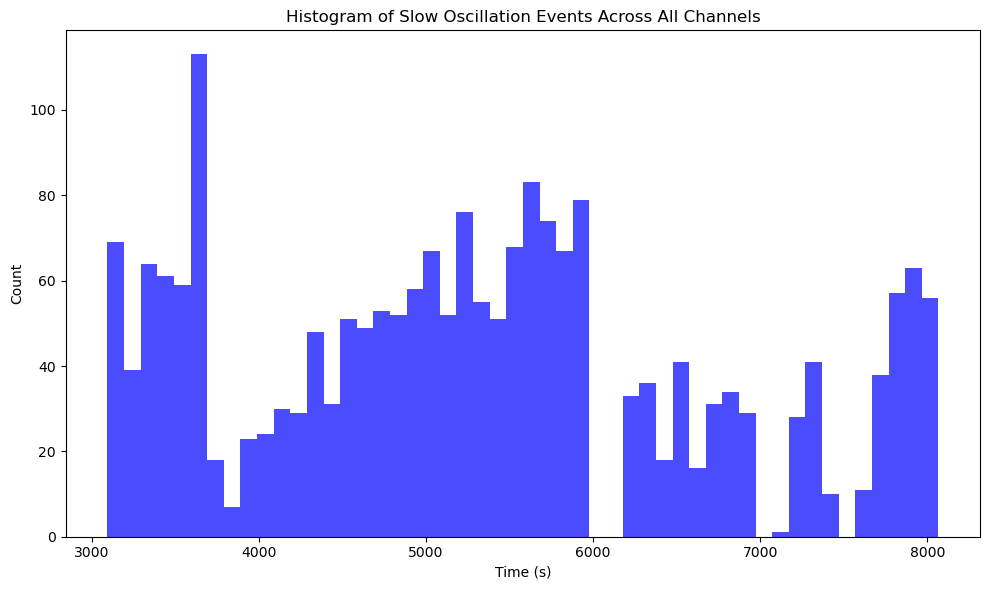

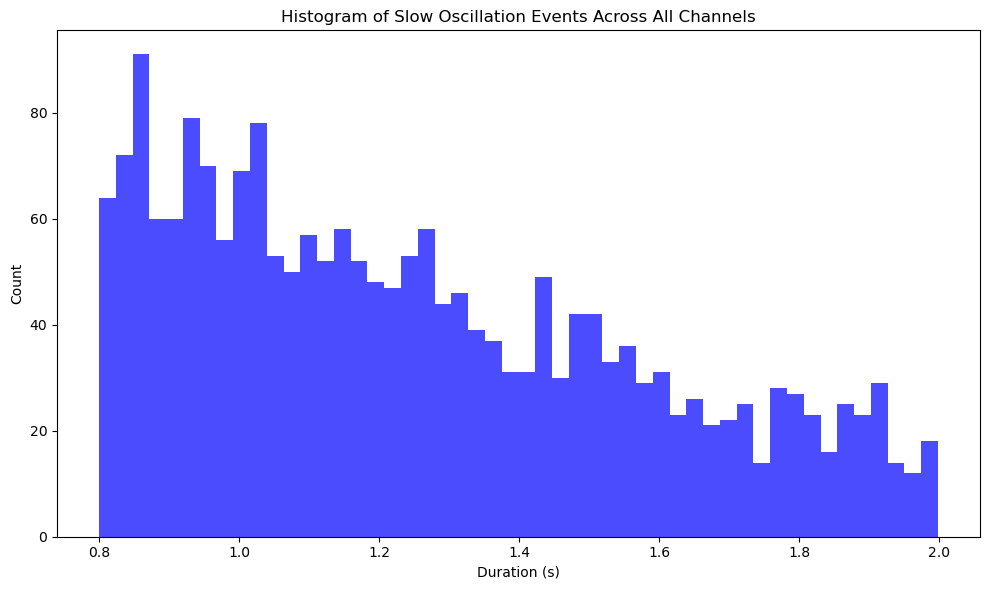

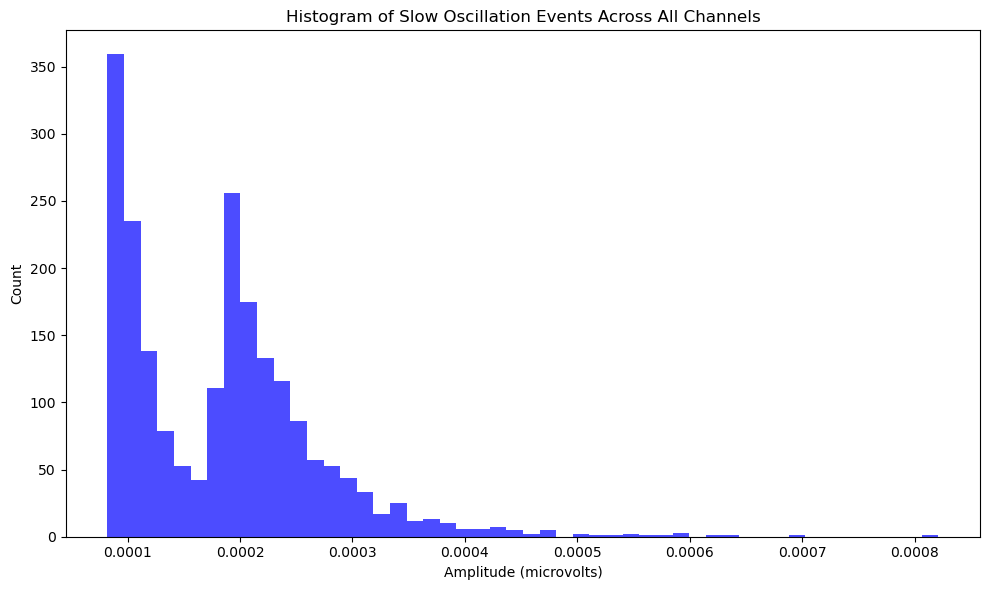

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(so_candidate['p2n_start'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(so_candidate['duration'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(so_candidate['ptp_amplitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Amplitude (microvolts)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

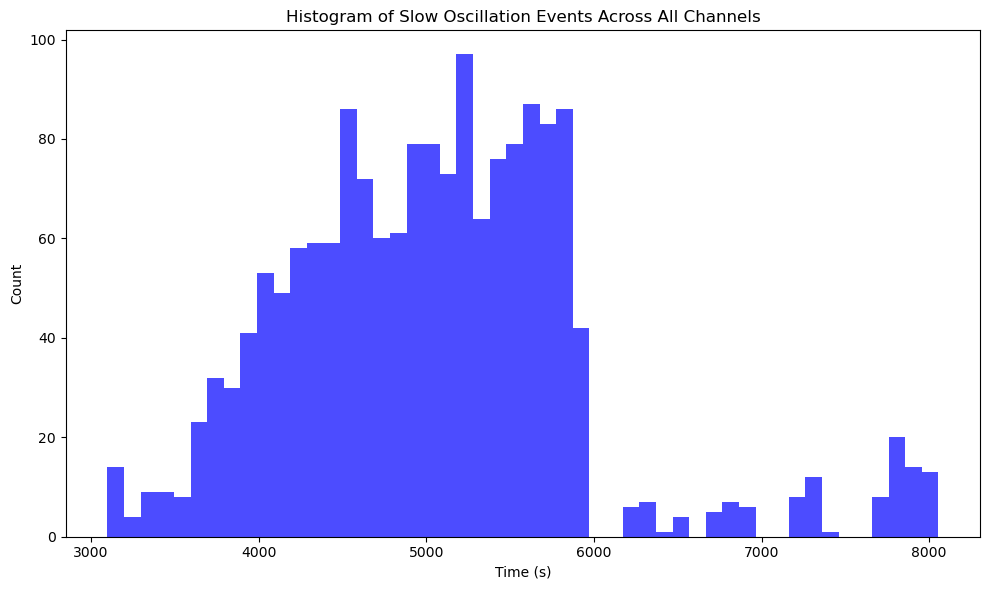

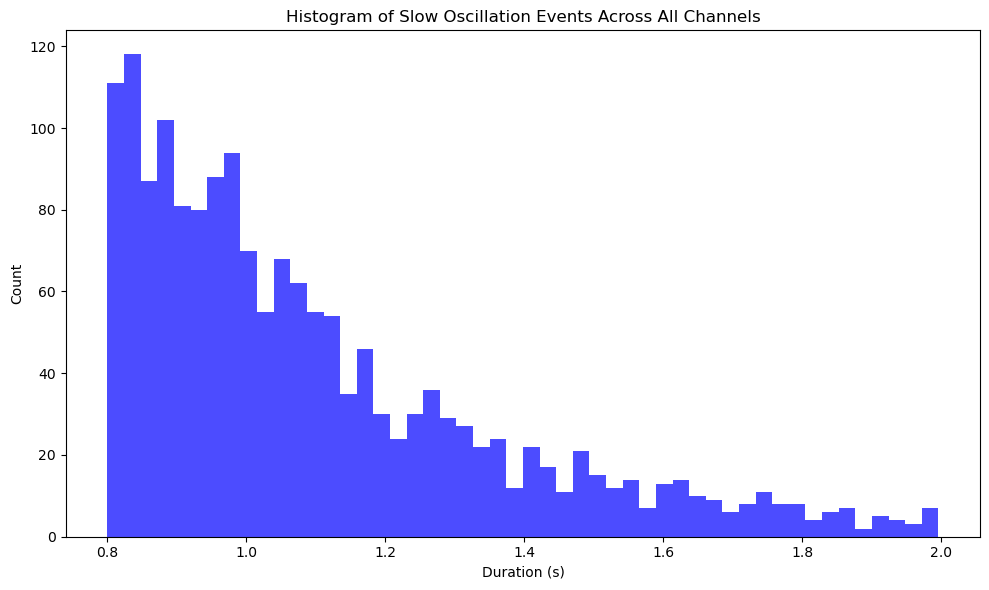

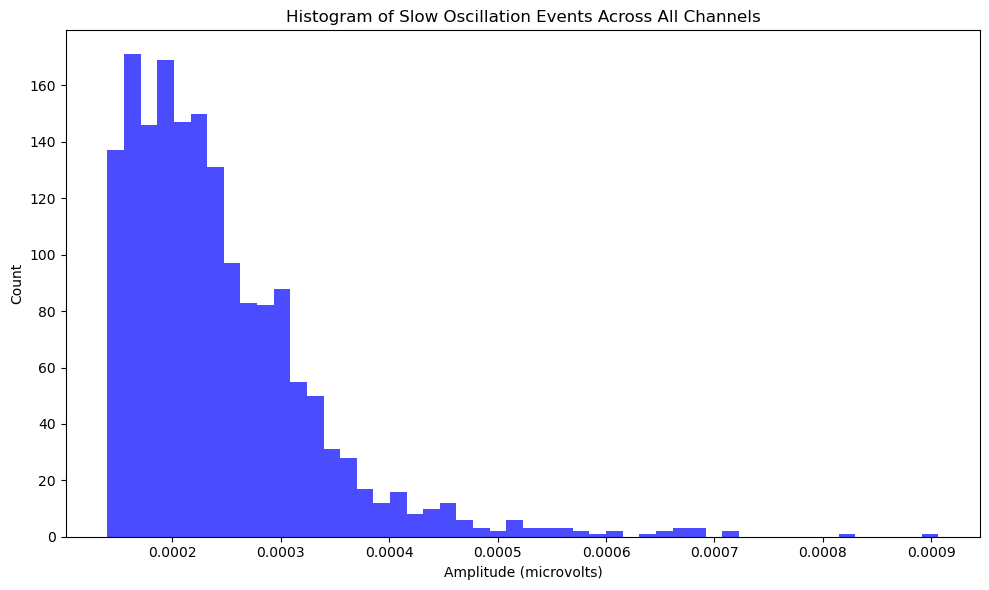

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(so_candidate_1['p2n_start'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(so_candidate_1['duration'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(so_candidate_1['ptp_amplitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Amplitude (microvolts)")
plt.ylabel("Count")
plt.title("Histogram of Slow Oscillation Events Across All Channels")
plt.tight_layout()
plt.show()

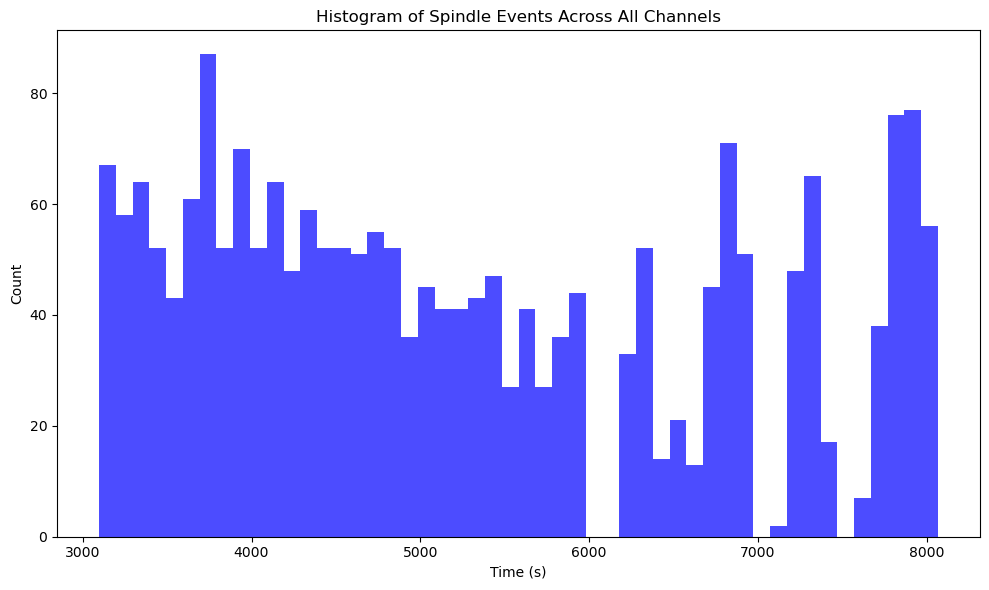

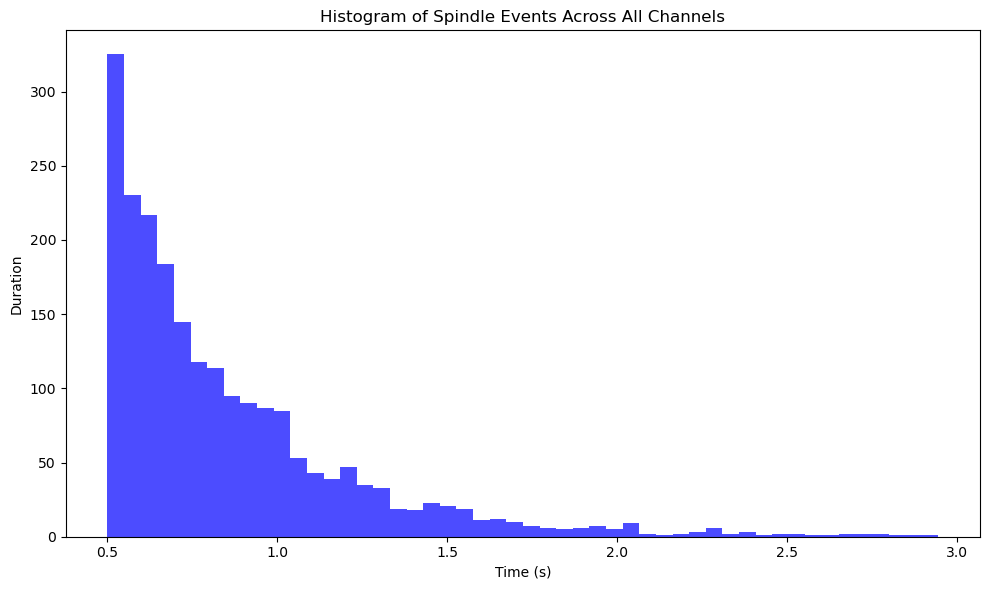

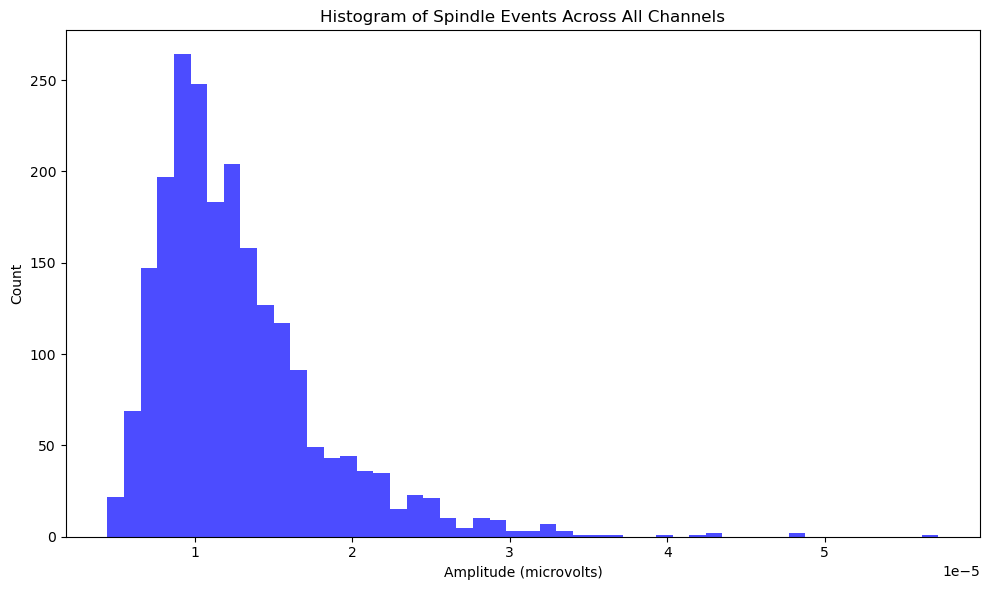

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(sp_candidate['peak_time'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(sp_candidate['duration'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Duration")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(sp_candidate['amplitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Amplitude (microvolts)")
plt.ylabel("Count")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

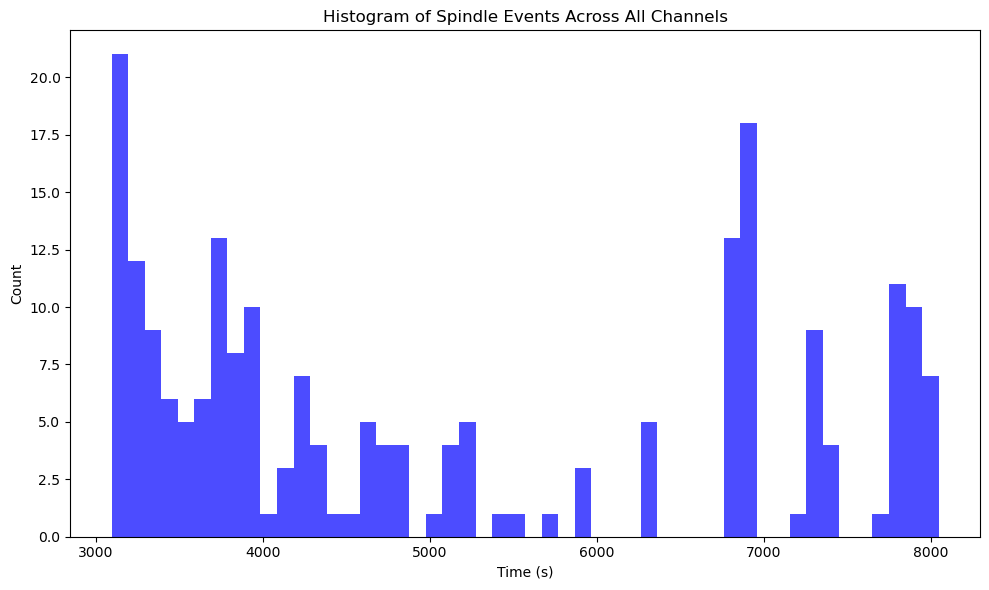

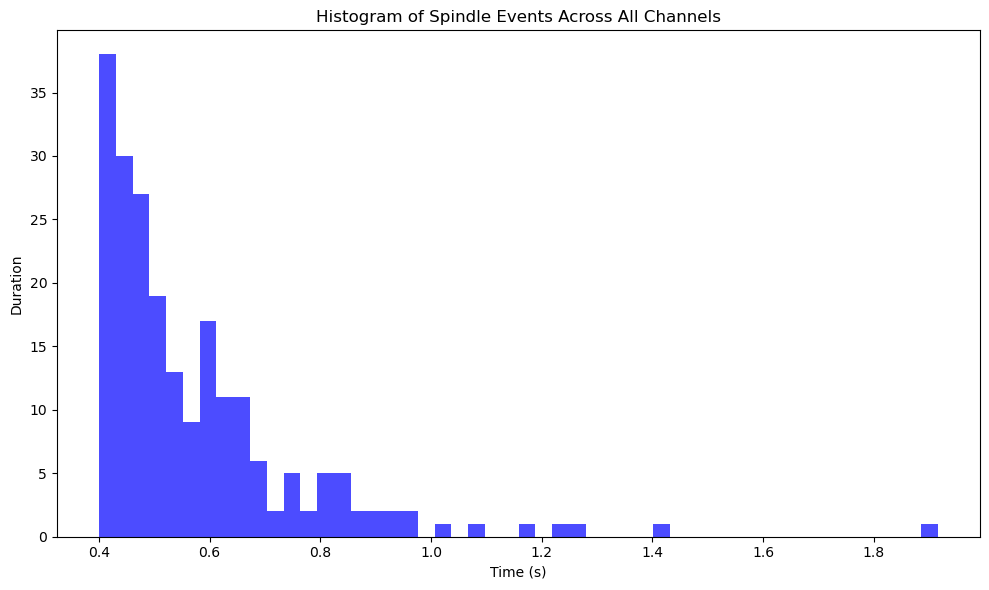

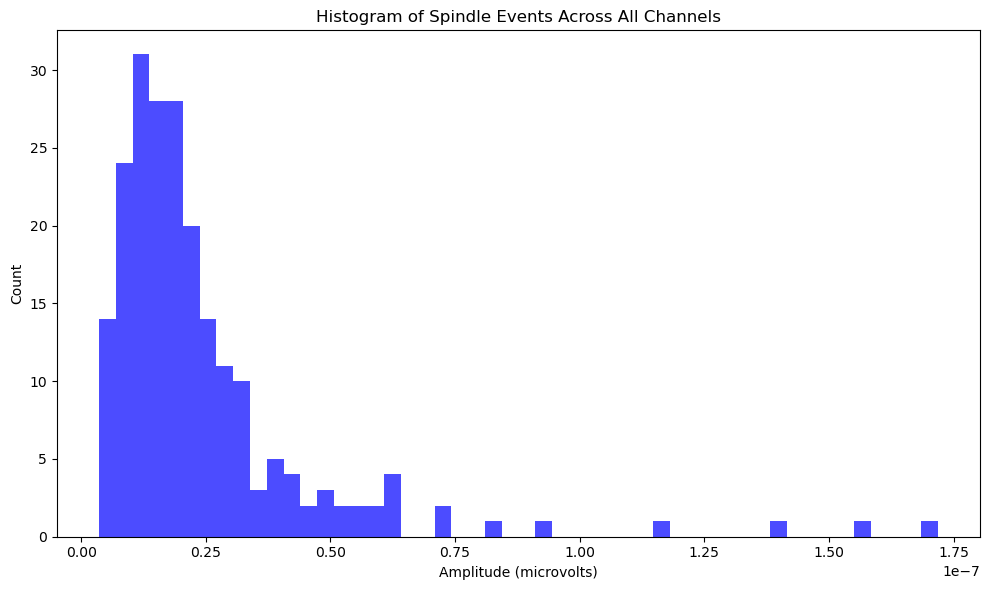

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(sp_candidate_1['peak_time'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(sp_candidate_1['duration'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Duration")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(sp_candidate_1['amplitude'], bins=50, color='blue', alpha=0.7)
plt.xlabel("Amplitude (microvolts)")
plt.ylabel("Count")
plt.title("Histogram of Spindle Events Across All Channels")
plt.tight_layout()
plt.show()

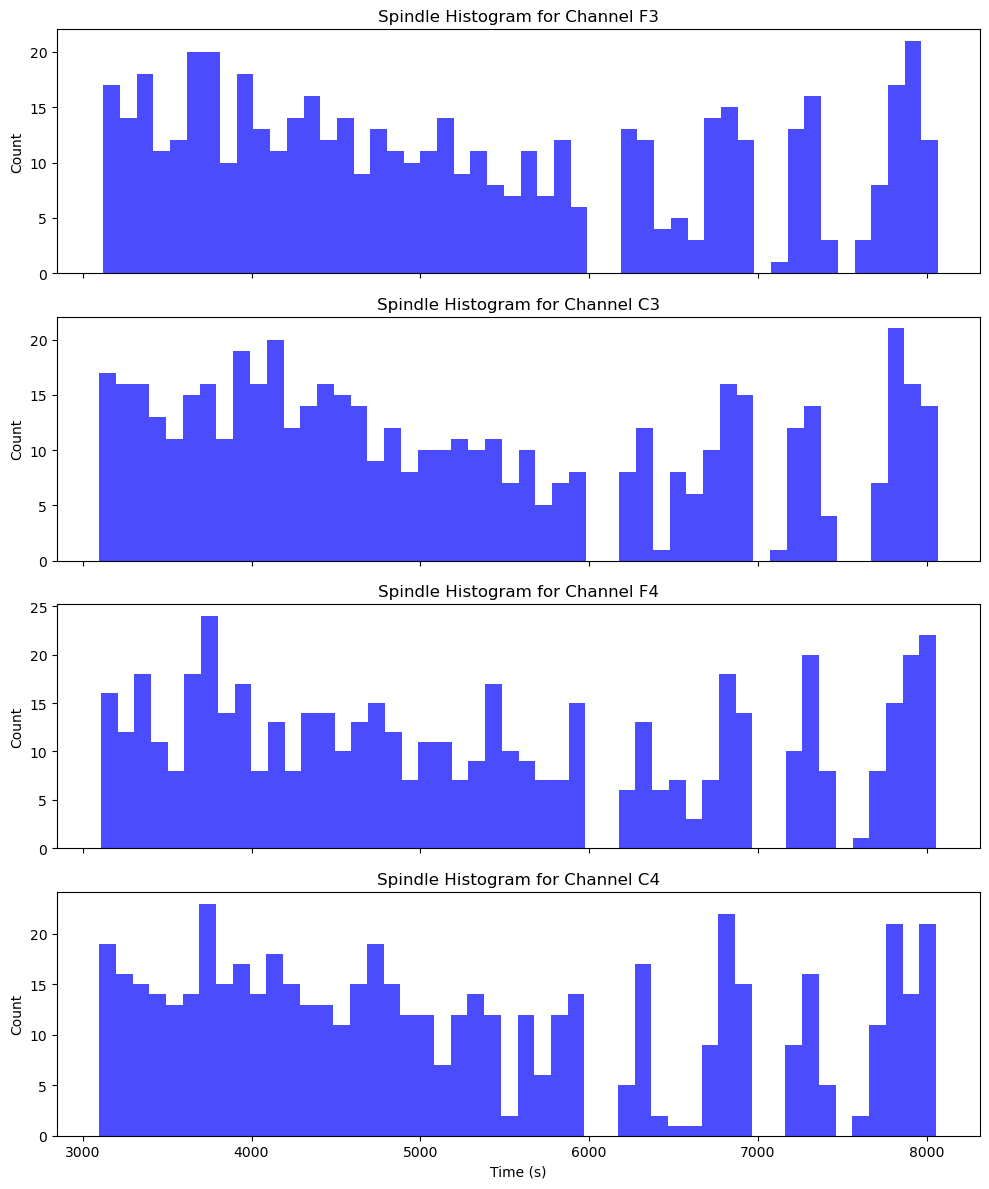

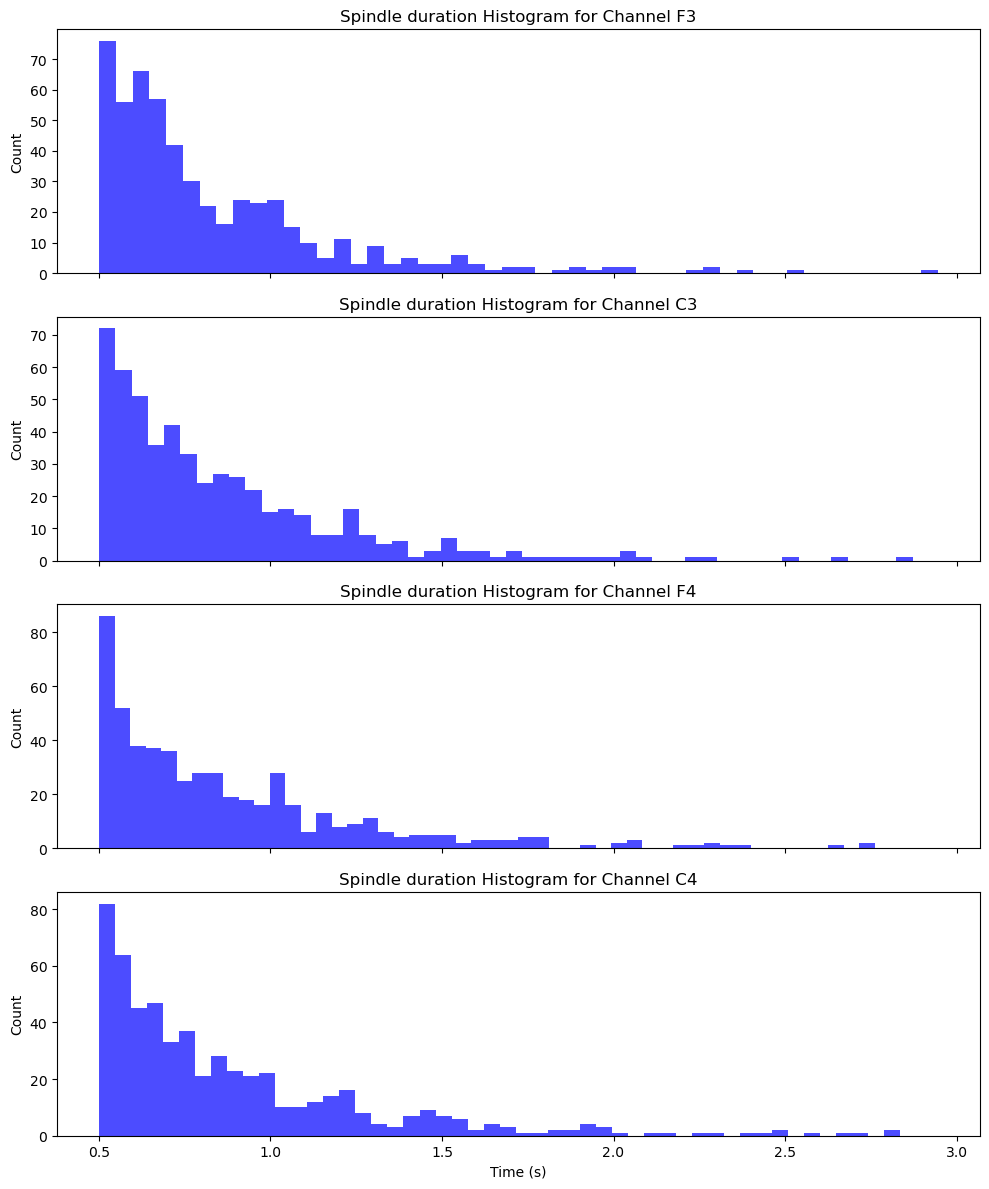

In [19]:
channels = sp_candidate['ch_name'].unique()
n_channels = len(channels)

# Create a figure with one subplot per channel
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)

# If there's only one channel, ensure axes is iterable
if n_channels == 1:
    axes = [axes]

# Loop over channels and plot the histogram for each
for ax, ch in zip(axes, channels):
    # Filter data for the current channel
    channel_data = sp_candidate[sp_candidate['ch_name'] == ch]
    
    # Plot histogram of spindle start times
    ax.hist(channel_data['peak_time'], bins=50, color='blue', alpha=0.7)
    ax.set_title(f"Spindle Histogram for Channel {ch}")
    ax.set_ylabel("Count")
    
# Set common x-axis label
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

channels = sp_candidate['ch_name'].unique()
n_channels = len(channels)

# Create a figure with one subplot per channel
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)

# If there's only one channel, ensure axes is iterable
if n_channels == 1:
    axes = [axes]

axes[-1].set_xlabel("Duration (s)")
# Loop over channels and plot the histogram for each
for ax, ch in zip(axes, channels):
    # Filter data for the current channel
    channel_data = sp_candidate[sp_candidate['ch_name'] == ch]
    
    # Plot histogram of spindle start times
    ax.hist(channel_data['duration'], bins=50, color='blue', alpha=0.7)
    ax.set_title(f"Spindle duration Histogram for Channel {ch}")
    ax.set_ylabel("Count")
    
# Set common x-axis label
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [20]:
print(sp_candidate)

      ch_id ch_name  start_time  end_time  peak_time  duration  amplitude  \
0         1      F3    3120.516  3121.220   3120.996     0.704   0.000013   
1         1      F3    3124.576  3125.292   3124.882     0.716   0.000011   
2         1      F3    3141.042  3142.128   3141.474     1.086   0.000024   
3         1      F3    3151.080  3151.634   3151.270     0.554   0.000021   
4         1      F3    3152.416  3153.976   3153.168     1.560   0.000034   
...     ...     ...         ...       ...        ...       ...        ...   
2148      4      C4    5910.772  5911.332   5911.152     0.560   0.000008   
2149      4      C4    5914.682  5915.242   5915.106     0.560   0.000008   
2150      4      C4    5915.398  5915.902   5915.626     0.504   0.000013   
2151      4      C4    5916.244  5916.798   5916.652     0.554   0.000009   
2152      4      C4    5918.074  5918.750   5918.226     0.676   0.000005   

      stage  z_amplitude  z_duration  
0         2     0.044389   -0.450378

In [21]:
# print(len(event_summary_all['MD_02']))
display(event_summary_all)


{'MD_02':    stage  preferred_phase  modulation_index  mean_vector_length  rayleigh_z  \
 0    all         1.251991          0.006438            0.013254    0.174259   
 1      2        -0.863785          0.007328            0.048528    1.215165   
 2      3         1.938521          0.015755            0.070971    2.397549   
 3    all         0.765727          0.015871            0.054846    0.977615   
 4      2        -0.507123          0.019936            0.052039    0.438699   
 5      3         1.249176          0.036625            0.106362    1.843985   
 6    all         2.744162          0.019084            0.104081    1.722435   
 7      2        -2.802588          0.048902            0.092088    0.636009   
 8      3         2.358691          0.043389            0.146874    1.812035   
 9    all         1.127167          0.015486            0.024694    0.214656   
 10     2        -0.151138          0.015704            0.028792    0.161646   
 11     3         1.777032     

In [22]:
print(coupling_event_all)

{'MD_02': None}


In [23]:
print(so_waveform_all)

{'MD_02':   stage                                        so_waveform
0   all  -1.8775704517770182,-1.6707368118101356,-1.416...
1     2  -2.4012317093505655,-2.4015265741764185,-2.406...
2     3  -1.323577877751169,-0.8976185112488796,-0.3685...}
